<a href="https://colab.research.google.com/github/sl007ha/qqq-risk-monitor/blob/main/notebooks/06_walkforward_v2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
!pip install yfinance fredapi --quiet

import pandas as pd
import numpy as np
import yfinance as yf
from fredapi import Fred
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import brier_score_loss, roc_auc_score, average_precision_score
import matplotlib.pyplot as plt
from google.colab import userdata

fred = Fred(api_key=userdata.get('FRED_API_KEY'))

# 拉之前 notebook 准备好的 csv（现在 Colab 里可能已经丢了，重新生成或上传）
# 简化做法：把这个 notebook 写成自包含的，从头拉所有数据

# ===== 1. NDX 价格 =====
ndx_d = yf.download('^NDX', start='1985-01-01', end='2025-12-31', auto_adjust=True)
ndx_d = ndx_d[['Close']].copy()
ndx_d.columns = ['ndx_close']
ndx_d['ma200'] = ndx_d['ndx_close'].rolling(200).mean()
ndx_d['dist_200dma'] = (ndx_d['ndx_close'] / ndx_d['ma200']) - 1

ndx_m = ndx_d[['ndx_close']].resample('ME').last()
ndx_m['tsmom_12m'] = ndx_m['ndx_close'].pct_change(12)
ndx_m['dist_200dma'] = ndx_d['dist_200dma'].resample('ME').last()

# ===== 2. CAPE（用 2.1 的代码） =====
import requests, io
SHILLER_URL = "https://img1.wsimg.com/blobby/go/e5e77e0b-59d1-44d9-ab25-4763ac982e53/downloads/441f0d2c-37e4-4803-b4e2-8fe10407fbf6/ie_data.xls?ver=1778098504874"
response = requests.get(SHILLER_URL, timeout=30)
shiller = pd.read_excel(io.BytesIO(response.content), sheet_name='Data', skiprows=7)
shiller = shiller.dropna(subset=['Date'])
shiller = shiller[shiller['Date'].apply(lambda x: isinstance(x, (int, float)))]

def shiller_date_to_ts(d):
    year = int(d)
    month = round((d - year) * 100)
    if month == 0:
        month = 1
    return pd.Timestamp(year=year, month=month, day=1) + pd.offsets.MonthEnd(0)

shiller['date'] = shiller['Date'].apply(shiller_date_to_ts)
shiller = shiller.set_index('date')

cape_df = shiller[['CAPE']].copy()
cape_df.columns = ['cape']
cape_df = cape_df.dropna()

window = 240
cape_df['cape_z'] = (cape_df['cape'] - cape_df['cape'].rolling(window, min_periods=120).mean()) / cape_df['cape'].rolling(window, min_periods=120).std()

# ===== 3. 收益率曲线 =====
yc = fred.get_series('T10Y3M', observation_start='1985-01-01').resample('ME').last().to_frame('yc_10y3m')

# ===== 4. CFNAI =====
cfnai = fred.get_series('CFNAIMA3', observation_start='1985-01-01').resample('ME').last().to_frame('cfnai_ma3')

# ===== 5. AAII（你需要先把 sentiment.xls 上传到 /content/） =====
import os
if os.path.exists('/content/sentiment.xls'):
    aaii_raw = pd.read_excel('/content/sentiment.xls', sheet_name=0, skiprows=3)
    # ... 用 2.3.3 的清洗代码处理 ...
    # 简化：假设你已经把 aaii.csv 也上传了
    aaii_m = pd.read_csv('/content/aaii.csv', index_col=0, parse_dates=True)
else:
    print("⚠️ aaii.csv 没找到，AAII 特征会缺失。先把 2.3 的输出上传到 /content/aaii.csv")
    aaii_m = pd.DataFrame(index=ndx_m.index, columns=['bb_spread'])

# ===== 6. 合并 =====
features_v2 = pd.DataFrame(index=ndx_m.index)
features_v2['cape_z'] = cape_df['cape_z']
features_v2['dist_200dma'] = ndx_m['dist_200dma']
features_v2['tsmom_12m'] = ndx_m['tsmom_12m']
features_v2['yc_10y3m'] = yc['yc_10y3m']
features_v2['cfnai_ma3'] = cfnai['cfnai_ma3']
features_v2['bb_spread'] = aaii_m['bb_spread']

# 看缺失情况
print(features_v2.isna().sum())
print(features_v2.dropna().index.min(), '->', features_v2.dropna().index.max())

[*********************100%***********************]  1 of 1 completed


cape_z          0
dist_200dma     9
tsmom_12m      12
yc_10y3m        0
cfnai_ma3       0
bb_spread      21
dtype: int64
1987-07-31 00:00:00 -> 2025-12-31 00:00:00


In [6]:
def future_max_drawdown(prices, current_idx, horizon_days=126):
    if current_idx + horizon_days >= len(prices):
        return np.nan
    future_prices = prices.iloc[current_idx : current_idx + horizon_days + 1]
    running_max = future_prices.cummax()
    drawdown = (future_prices / running_max) - 1
    return drawdown.min()

month_ends = ndx_d.resample('ME').last().index
labels = []
for d in month_ends:
    if (ndx_d.index <= d).any():
        d_actual = ndx_d.index[ndx_d.index <= d][-1]
    else:
        labels.append((d, np.nan)); continue
    idx = ndx_d.index.get_loc(d_actual)
    mdd = future_max_drawdown(ndx_d['ndx_close'], idx)
    labels.append((d, mdd))

labels_df = pd.DataFrame(labels, columns=['date', 'future_6m_mdd']).set_index('date')
labels_df['label_15'] = (labels_df['future_6m_mdd'] <= -0.15).astype(int)

df_v2 = features_v2.join(labels_df[['label_15']], how='inner').dropna()
print(f"v2 训练用样本数：{len(df_v2)}")
print(f"起始：{df_v2.index.min()}，终止：{df_v2.index.max()}")
print(f"label_15 分布：{df_v2['label_15'].value_counts().to_dict()}")

v2 训练用样本数：462
起始：1987-07-31 00:00:00，终止：2025-12-31 00:00:00
label_15 分布：{0: 323, 1: 139}


In [7]:
def walk_forward_v2(df, embargo_months=6, train_min_samples=60, train_min_positives=5):
    """
    严格 walk-forward：
    - 每个月一个 cutoff
    - 训练集必须早于 cutoff - embargo_months 之前结束
    - 训练集至少 train_min_samples 行 + train_min_positives 个正样本
    """
    results = []
    all_dates = sorted(df.index.tolist())

    for i, cutoff in enumerate(all_dates):
        cutoff_train_end = cutoff - pd.DateOffset(months=embargo_months)
        train_part = df[df.index < cutoff_train_end]
        test_part = df[df.index == cutoff]

        if len(train_part) < train_min_samples:
            continue
        if train_part['label_15'].sum() < train_min_positives:
            continue
        if len(test_part) == 0:
            continue

        X_tr = train_part.drop(columns=['label_15'])
        y_tr = train_part['label_15']
        X_te = test_part.drop(columns=['label_15'])

        sc = StandardScaler().fit(X_tr)
        m = LogisticRegression(C=1.0, max_iter=1000, random_state=42, class_weight='balanced').fit(sc.transform(X_tr), y_tr)
        p = m.predict_proba(sc.transform(X_te))[0, 1]

        results.append({
            'date': cutoff,
            'p_15': p,
            'label': test_part['label_15'].iloc[0]
        })

    return pd.DataFrame(results).set_index('date')

wf_v2 = walk_forward_v2(df_v2, embargo_months=6)
print(f"Walk-forward 输出 {len(wf_v2)} 行")
print(wf_v2.head())

Walk-forward 输出 396 行
                p_15  label
date                       
1993-01-31  0.668822      0
1993-02-28  0.691622      0
1993-03-31  0.550741      0
1993-04-30  0.681353      0
1993-05-31  0.676890      0


In [8]:
# 只在 OOS 段（去掉初始训练段）评估
# 严格 OOS：第一个有训练数据的预测之后的所有预测
oos_v2 = wf_v2.dropna()

brier = brier_score_loss(oos_v2['label'], oos_v2['p_15'])
baseline_brier = brier_score_loss(oos_v2['label'], [oos_v2['label'].mean()] * len(oos_v2))
roc_auc = roc_auc_score(oos_v2['label'], oos_v2['p_15'])
pr_auc = average_precision_score(oos_v2['label'], oos_v2['p_15'])

print(f"OOS Brier:   {brier:.4f}")
print(f"基线 Brier:   {baseline_brier:.4f}  (越低越好)")
print(f"OOS ROC-AUC: {roc_auc:.3f}")
print(f"OOS PR-AUC:  {pr_auc:.3f}  (vs base rate {oos_v2['label'].mean():.3f})")

OOS Brier:   0.2760
基线 Brier:   0.2132  (越低越好)
OOS ROC-AUC: 0.525
OOS PR-AUC:  0.328  (vs base rate 0.308)


/tmp/ipykernel_68273/595435579.py:18: UserWarning: Glyph 31185 (\N{CJK UNIFIED IDEOGRAPH-79D1}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_68273/595435579.py:18: UserWarning: Glyph 25216 (\N{CJK UNIFIED IDEOGRAPH-6280}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_68273/595435579.py:18: UserWarning: Glyph 29066 (\N{CJK UNIFIED IDEOGRAPH-718A}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_68273/595435579.py:19: UserWarning: Glyph 31185 (\N{CJK UNIFIED IDEOGRAPH-79D1}) missing from font(s) DejaVu Sans.
  plt.savefig('/content/crashes_v2.png', dpi=100)
/tmp/ipykernel_68273/595435579.py:19: UserWarning: Glyph 25216 (\N{CJK UNIFIED IDEOGRAPH-6280}) missing from font(s) DejaVu Sans.
  plt.savefig('/content/crashes_v2.png', dpi=100)
/tmp/ipykernel_68273/595435579.py:19: UserWarning: Glyph 29066 (\N{CJK UNIFIED IDEOGRAPH-718A}) missing from font(s) DejaVu Sans.
  plt.savefig('/content/crashes_v2.png', dpi=100)
/usr/lo

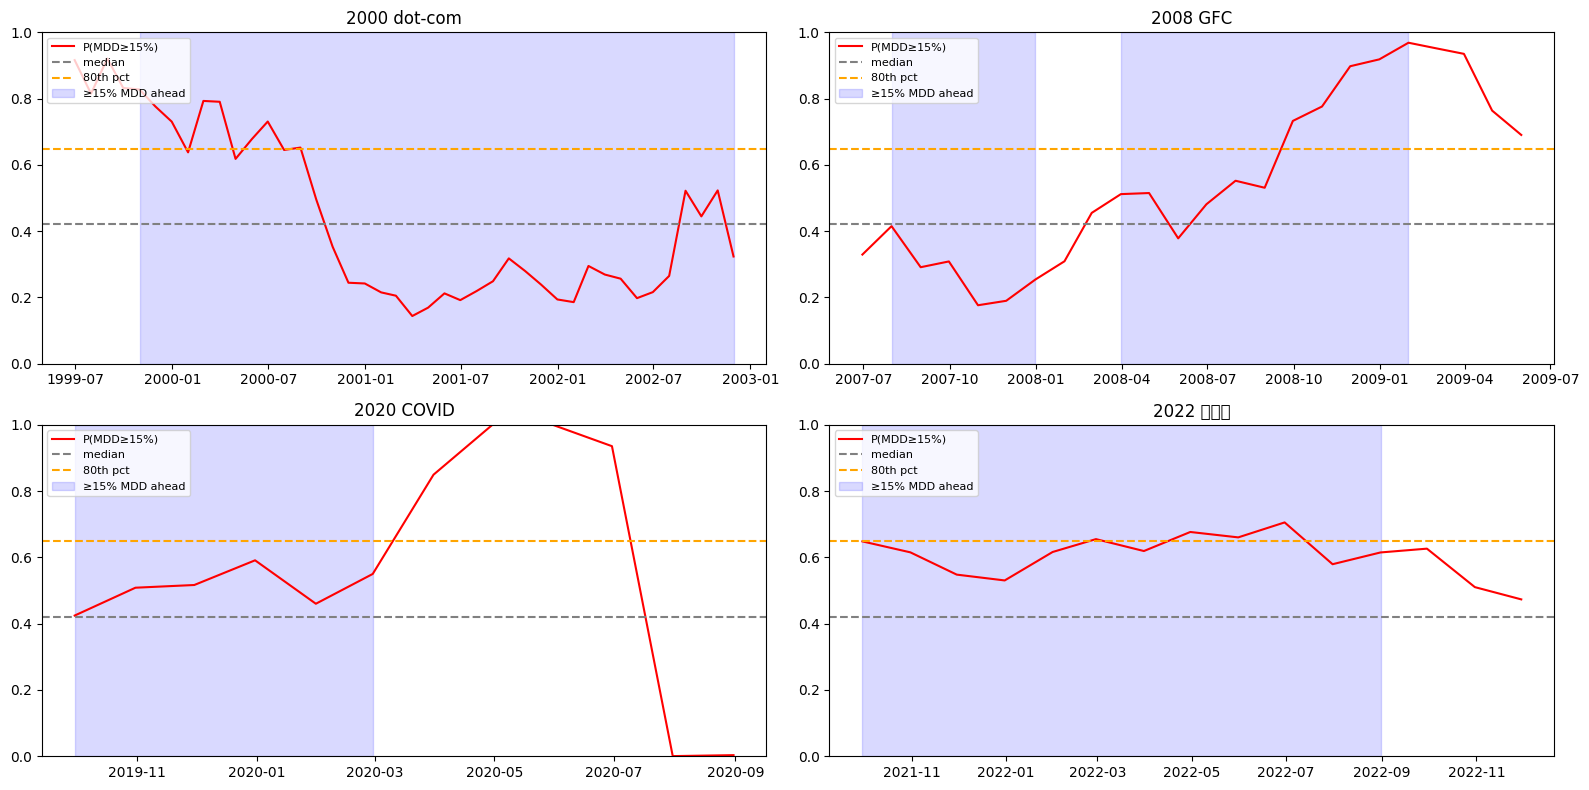

In [9]:
crashes = {
    '2000 dot-com': ('1999-06-01', '2002-12-01'),
    '2008 GFC':     ('2007-06-01', '2009-06-01'),
    '2020 COVID':   ('2019-09-01', '2020-09-01'),
    '2022 科技熊':   ('2021-09-01', '2022-12-01'),
}

fig, axes = plt.subplots(2, 2, figsize=(16, 8))
for ax, (name, (start, end)) in zip(axes.flat, crashes.items()):
    sub = wf_v2[(wf_v2.index >= start) & (wf_v2.index <= end)]
    ax.plot(sub.index, sub['p_15'], color='red', label='P(MDD≥15%)')
    ax.axhline(wf_v2['p_15'].quantile(0.5), color='gray', linestyle='--', label='median')
    ax.axhline(wf_v2['p_15'].quantile(0.8), color='orange', linestyle='--', label='80th pct')
    ax.fill_between(sub.index, 0, 1, where=sub['label']==1, alpha=0.15, color='blue', label='≥15% MDD ahead')
    ax.set_title(name)
    ax.set_ylim(0, 1)
    ax.legend(loc='upper left', fontsize=8)
plt.tight_layout()
plt.savefig('/content/crashes_v2.png', dpi=100)
plt.show()

In [10]:
# 在 wf_v2 上分时段算指标
periods = {
    'all_oos': (None, None),
    '2007–2009': ('2007-01', '2009-12'),
    '2015–2026': ('2015-01', '2026-12'),  # 跟 Phase 1 OOS 段对比
}

print(f"{'Period':<15} {'N':<6} {'Brier':<10} {'Baseline':<10} {'AUC':<8} {'PR-AUC':<10}")
print('-' * 70)
for name, (start, end) in periods.items():
    sub = wf_v2.copy()
    if start: sub = sub[sub.index >= start]
    if end: sub = sub[sub.index <= end]
    sub = sub.dropna()
    if len(sub) < 10:
        continue

    brier = brier_score_loss(sub['label'], sub['p_15'])
    baseline = brier_score_loss(sub['label'], [sub['label'].mean()] * len(sub))
    auc = roc_auc_score(sub['label'], sub['p_15']) if sub['label'].nunique() > 1 else float('nan')
    pr = average_precision_score(sub['label'], sub['p_15']) if sub['label'].nunique() > 1 else float('nan')
    print(f"{name:<15} {len(sub):<6} {brier:<10.4f} {baseline:<10.4f} {auc:<8.3f} {pr:<10.3f}")

Period          N      Brier      Baseline   AUC      PR-AUC    
----------------------------------------------------------------------
all_oos         396    0.2760     0.2132     0.525    0.328     
2007–2009       35     0.2622     0.2498     0.637    0.619     
2015–2026       132    0.2291     0.1948     0.715    0.417     
